---
title: Predict El Nino indices using CNNs
author: Harsha R. Hampapura
date: 07-03-2026
---

**Adapted from:**
- [NCAR ML Workshop 2023 — Linear Models Tutorial](https://github.com/NCAR/ML_workshop2023/blob/main/tutorials/Day1_simple_regression/Linear_Models.ipynb)
- [NCAR AIML Tutorial — CNN Predict ENSO](https://github.com/NCAR/AIML-Tutorial/blob/main/Lecture2_ANNvsCNN/CNN_PredictENSO.ipynb)

---

## Introduction

This notebook demonstrates a **GPU-accelerated CNN workflow** that:
1. Restricts the spatial domain to the **tropical Pacific** (30°S–30°N) where the ENSO signal is strongest.
2. Classifies each SST map as **El Niño or La Niña** using a CNN trained on GPU.
3. Uses **TensorFlow/Keras** for model definition, training, and inference on a single NVIDIA GPU (V100, A100, or H100 on Casper).
4. The input dataset is **ERSSTv5** (deseasoned, detrended, 5-month running mean applied) hosted on NCAR's [Geoscience Data Exchange (GDEX)](https://gdex.ucar.edu).

### We need the following packages to run this notebook

| Package | Version | Notes |
|---------|---------|-------|
| Python | 3.11 | |
| TensorFlow | 2.18.0 | compiled against cuDNN 9.1.x |
| Keras | 3.7.0 | |
| xarray | 2026.1.0 | |
| CUDA runtime | 12.9 | |
| cuDNN | 9.1.0 | |

> **Note on version compatibility:** TensorFlow must be compiled against a cuDNN
> version that matches the system installation. On Casper (cuDNN 9.1.0),
> TensorFlow 2.18.0 is the correct choice. Using TensorFlow 2.21.0 (compiled
> against cuDNN 9.3.0) will cause a `DNN library initialization failed` error
> at training time.

In [1]:
# Imports
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # suppress oneDNN warnings

import sys
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xarray as xr
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import dask

In [2]:
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.size'] = 12
#
# TensorFlow / Keras
import keras
import tensorflow as tf

# Set seeds for reproducibility
RANDOM_SEED = 36
np.random.seed(RANDOM_SEED)
keras.utils.set_random_seed(RANDOM_SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"GPUs visible       : {tf.config.list_physical_devices('GPU')}")

2026-04-07 16:16:43.215401: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775600203.231053   21326 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775600203.236261   21326 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-07 16:16:43.255642: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version : 2.18.0
Keras version      : 3.7.0
GPUs visible       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Confirm GPU details from TensorFlow's perspective
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
        details = tf.config.experimental.get_device_details(gpu)
        print(f"GPU name         : {details.get('device_name', 'unknown')}")
        print(f"Compute capability: {details.get('compute_capability', 'unknown')}")
else:
    print("!! No GPU detected — see §1 for how to start a GPU session !!")

# Confirm TensorFlow will place ops on the GPU by default
print(f"\nDefault GPU       : {tf.test.gpu_device_name()}")
print(f"Built with CUDA   : {tf.test.is_built_with_cuda()}")

GPU name         : Tesla V100-SXM2-32GB
Compute capability: (7, 0)

Default GPU       : /device:GPU:0
Built with CUDA   : True


I0000 00:00:1775600204.882019   21326 gpu_device.cc:2022] Created device /device:GPU:0 with 31129 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:62:00.0, compute capability: 7.0


In [4]:
# ----------------- File paths and Hyperparameters ─────────────────
DATA_DIR  = "/gdex/data/special_projects/gdex_examples"
SST_FILE  = os.path.join(DATA_DIR, "ERSSTv5_deseasoneddetrended_5monthrunningmean_1950-2021.nc")
SCRATCH_DIR    = os.environ.get("SCRATCH", f"/glade/scratch/{os.environ.get('USER', 'user')}")
MODEL_SAVE_DIR = os.path.join(SCRATCH_DIR, "saved_model")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# ── ENSO event threshold ──────────────────────────────────────────────────────
ENSO_MAGNITUDE = 0.5   # El Niño: >= +0.5,  La Niña: <= -0.5

# ── Train / validation / test split ──────────────────────────────────────────
TRAIN_VAL_TEST = [0.7, 0.85, 1.0]   # cumulative fractions

# ── CNN architecture ──────────────────────────────────────────────────────────
FILTERS     = [4]
KERNEL_SIZE = [[2, 2]]
DENSE       = [4]
RIDGE_PEN   = 0.0
ACT_FUNC    = 'relu'

# ── Training hyperparameters ──────────────────────────────────────────────────
LEARNING_RATE = 0.1
N_EPOCHS      = 20
BATCH_SIZE    = 32
OPTIMIZER     = 'adam'
LOSS_FUNC     = 'categorical_crossentropy'

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 36
np.random.seed(RANDOM_SEED)
keras.utils.set_random_seed(RANDOM_SEED)

### Helper functions ######

In [5]:
def get_data(filepath):
    sstds = xr.open_dataset(filepath, engine= 'netcdf4',decode_times=False)
    return sstds.sst


def get_nino34(sst):
    ninolat1, ninolat2 = -5, 5
    ninolon1, ninolon2 = 190, 240
    sstnino = sst.sel(lat=slice(ninolat1, ninolat2),
                      lon=slice(ninolon1, ninolon2)).values
    return np.nanmean(sstnino, axis=(1, 2))


def get_nino34events(sst, nino34, enso_magnitude, vectorize=False):
    mask = (nino34 > enso_magnitude) | (nino34 < -enso_magnitude)
    x = sst[mask, :, :]
    if vectorize:
        x = x.reshape(x.shape[0], -1)
    y = nino34[mask]
    return x, y


def split_data(num_samples, train_val_test, x, y):
    trainind = range(int(train_val_test[0] * num_samples))
    valind   = range(int(train_val_test[0] * num_samples),
                     int(train_val_test[1] * num_samples))
    testind  = range(int(train_val_test[1] * num_samples),
                     int(train_val_test[2] * num_samples))
    return (x[trainind], x[valind], x[testind],
            y[trainind], y[valind], y[testind],
            trainind, valind, testind)


def standardize_data(xtrain, xval, xtest):
    xstd = np.std(xtrain, axis=0)
    xtrain = np.divide(xtrain, xstd);  xtrain[np.isnan(xtrain)] = 0
    xval   = np.divide(xval,   xstd);  xval[np.isnan(xval)]     = 0
    xtest  = np.divide(xtest,  xstd);  xtest[np.isnan(xtest)]   = 0
    return xtrain, xval, xtest


def make_cat(y, enso_magnitude):
    y = y.copy()
    y[y >  enso_magnitude] = 1
    y[y < -enso_magnitude] = 0
    return y


def plot_nino34(nino34):
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.plot(np.arange(1950 + 5/12, 2022, 1/12), nino34, color='xkcd:slate blue')
    ax.axhline( 0.5, ls='dashed', color='grey')
    ax.axhline(-0.5, ls='dashed', color='grey')
    ax.set_xlim(1950, 2022)
    ax.set_ylim(-2.5, 2.5)
    ax.set_ylabel("Nino 3.4 Index")
    plt.tight_layout()
    plt.show()


def plot_input(sst, lon, lat):
    projection = ccrs.PlateCarree(central_longitude=180)
    transform  = ccrs.PlateCarree()
    fig, ax = plt.subplots(figsize=(8, 4),
                           subplot_kw=dict(projection=projection))
    ax.pcolormesh(lon, lat, sst, vmin=-2, vmax=2,
                  cmap='RdBu_r', transform=transform)
    ax.coastlines(color='gray')
    ax.set_frame_on(False)
    ax.set_title('Example Input')
    plt.tight_layout()
    plt.show()


def plot_datasplit(nino34, enso_magnitude, trainind, valind, testind):
    timevec = np.arange(1950 + 5/12, 2022, 1/12)
    mask    = (nino34 > enso_magnitude) | (nino34 < -enso_magnitude)
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.scatter(timevec[mask][trainind], nino34[mask][trainind],
               color='xkcd:slate blue', s=8, label='train')
    ax.scatter(timevec[mask][valind],   nino34[mask][valind],
               color='indianred',       s=8, label='validation')
    ax.scatter(timevec[mask][testind],  nino34[mask][testind],
               color='coral',           s=8, label='test')
    ax.axhline( enso_magnitude, ls='dashed', color='grey')
    ax.axhline(-enso_magnitude, ls='dashed', color='grey')
    ax.set_xlim(1950, 2022)
    ax.set_ylim(-2.5, 2.5)
    ax.set_ylabel("Nino 3.4 Index")
    ax.legend(bbox_to_anchor=(1, 0.4, .1, 0.2))
    plt.tight_layout()
    plt.show()

## Load Data

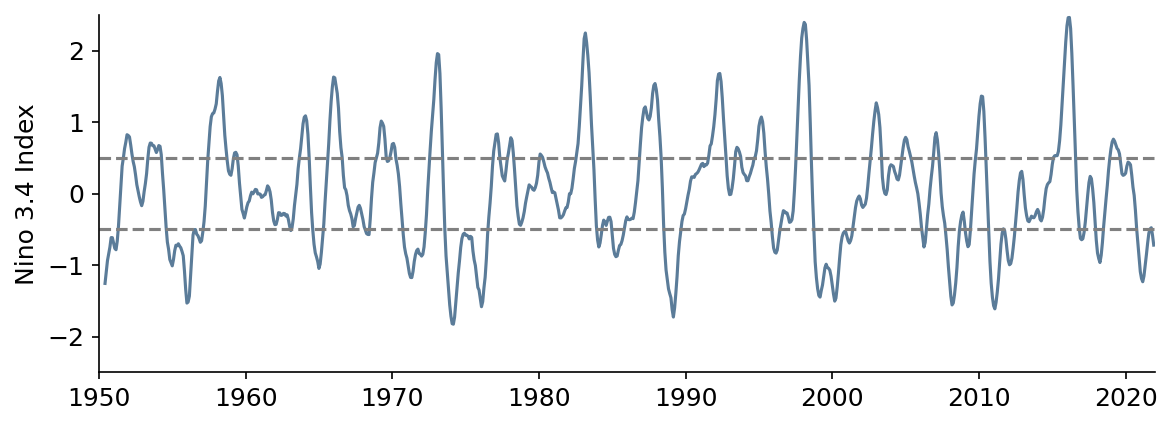

xtrain : (324, 1, 31, 180)   ytrain : (324, 2)
xval   : (70, 1, 31, 180)     yval   : (70, 2)
xtest  : (70, 1, 31, 180)    ytest  : (70, 2)


In [6]:
# ── Load data ─────────────────────────────────────────────────────────────────
sst_all = get_data(SST_FILE)

# Restrict to tropical Pacific (30°S–30°N)
sst = sst_all.where(
    (sst_all.lat <= 30) & (sst_all.lat >= -30), drop=True
)

lat = np.asarray(sst.lat)
lon = np.asarray(sst.lon)

# ── Compute Nino3.4 index ─────────────────────────────────────────────────────
nino34 = get_nino34(sst)
plot_nino34(nino34)

# ── Grab only El Niño / La Niña samples ───────────────────────────────────────
sst_np = np.asarray(sst)
x, y   = get_nino34events(sst_np, nino34, ENSO_MAGNITUDE, vectorize=False)

# ── Train / val / test split ──────────────────────────────────────────────────
num_samples = y.shape[0]
xtrain, xval, xtest, ytrain, yval, ytest, trainind, valind, testind = split_data(
    num_samples, TRAIN_VAL_TEST, x, y
)

# ── Standardise by training std ───────────────────────────────────────────────
xtrain, xval, xtest = standardize_data(xtrain, xval, xtest)

# ── Add channel dimension: (samples, lat, lon) → (samples, 1, lat, lon) ──────
# data_format='channels_first' is used in the CNN definition, matching
# the NCAR AIML tutorial convention.
xtrain = np.expand_dims(xtrain, axis=1)
xval   = np.expand_dims(xval,   axis=1)
xtest  = np.expand_dims(xtest,  axis=1)

# ── NaN → 0  (land grid cells; the CNN learns to ignore them) ─────────────────
xtrain[np.isnan(xtrain)] = 0
xval[np.isnan(xval)]     = 0
xtest[np.isnan(xtest)]   = 0

# ── Convert labels to one-hot categorical ─────────────────────────────────────
# 1 = El Niño,  0 = La Niña
ytrain = keras.utils.to_categorical(make_cat(ytrain, ENSO_MAGNITUDE))
yval   = keras.utils.to_categorical(make_cat(yval,   ENSO_MAGNITUDE))
ytest  = keras.utils.to_categorical(make_cat(ytest,  ENSO_MAGNITUDE))

print(f"xtrain : {xtrain.shape}   ytrain : {ytrain.shape}")
print(f"xval   : {xval.shape}     yval   : {yval.shape}")
print(f"xtest  : {xtest.shape}    ytest  : {ytest.shape}")

## GPU Execution in This Notebook

TensorFlow automatically places operations on the GPU when one is available —
there is no need to manually move data or models to the device as in PyTorch.
The table below summarises where each step of the workflow runs:

| Step | Location | Notes |
|------|----------|-------|
| Load NetCDF (`xr.open_dataset`) | CPU | File I/O always runs on CPU |
| Restrict to tropical Pacific | CPU | xarray selection |
| Compute Nino3.4 index | CPU | `np.nanmean` over a small region |
| Filter El Niño / La Niña events | CPU | NumPy boolean indexing |
| Train / val / test split | CPU | NumPy array slicing |
| Standardise by training std | CPU | NumPy division |
| `expand_dims`, NaN → 0 | CPU | NumPy operations |
| `to_categorical` | CPU | Keras utility |
| **CNN forward pass** | **GPU** | TensorFlow places `Conv2D`, `Dense`, `Flatten`, `MaxPooling2D` ops on `/device:GPU:0` automatically |
| **Backpropagation / weight update** | **GPU** | Gradient computation and Adam update run on GPU |
| **Batch iteration during `model.fit`** | **GPU** | Each batch is transferred CPU→GPU by TensorFlow's data pipeline |
| `model.predict` (inference) | **GPU** | Forward pass only, no gradient computation |

### Why is most preprocessing on the CPU?

The ERSSTv5 dataset for 1950–2021 is small (~5 MB). For a dataset this size
the cost of transferring data to the GPU for preprocessing is larger than the
cost of just doing it on the CPU with NumPy. GPU preprocessing (e.g. with CuPy)
becomes worthwhile for much larger datasets such as global daily fields at high
resolution, as demonstrated in the
[xarray GPU pipeline blog post](https://xarray.dev/blog/gpu-pipeline/).

### Confirming GPU placement

You can verify that TensorFlow is using the GPU during training by running:
```python
tf.debugging.set_log_device_placement(True)
```

before `model.fit`. This prints the device assignment for every op to stdout.
Disable it again afterwards with:
```python
tf.debugging.set_log_device_placement(False)
```

### Define the convolutional neural network

In [7]:
def defineCNN(filters, kernel_size, dense, input_shape, output_shape,
              ridge_penalty=0., lasso_penalty=0., act_fun='relu', network_seed=99):

    inputs = keras.Input(shape=input_shape)

    # First conv layer (with optional L1/L2 regularisation on input)
    x = keras.layers.Conv2D(filters[0],
                            kernel_size[0],
                            data_format='channels_first',
                            strides=(1, 1),
                            padding='valid',
                            activation=act_fun,
                            use_bias=True,
                            kernel_regularizer=keras.regularizers.l1_l2(
                                l1=lasso_penalty, l2=ridge_penalty),
                            bias_initializer=keras.initializers.RandomNormal(seed=network_seed),
                            kernel_initializer=keras.initializers.RandomNormal(seed=network_seed)
                            )(inputs)

    # Additional conv layers with MaxPooling
    for ilayer in range(len(filters))[1:]:
        x = keras.layers.MaxPooling2D((2, 2))(x)
        x = keras.layers.Conv2D(filters[ilayer],
                                kernel_size[ilayer],
                                data_format='channels_first',
                                strides=(1, 1),
                                activation=act_fun,
                                use_bias=True,
                                kernel_regularizer=keras.regularizers.l1_l2(l1=0., l2=0.),
                                bias_initializer=keras.initializers.RandomNormal(seed=network_seed),
                                kernel_initializer=keras.initializers.RandomNormal(seed=network_seed)
                                )(x)

    x = keras.layers.Flatten()(x)

    # Dense hidden layers
    for idenselayer in range(len(dense)):
        x = keras.layers.Dense(dense[idenselayer],
                               activation=act_fun,
                               use_bias=True,
                               kernel_regularizer=keras.regularizers.l1_l2(l1=0., l2=0.),
                               bias_initializer=keras.initializers.RandomNormal(seed=network_seed),
                               kernel_initializer=keras.initializers.RandomNormal(seed=network_seed)
                               )(x)

    # Output layer
    output_layer = keras.layers.Dense(output_shape,
                                      activation='softmax',
                                      use_bias=True,
                                      kernel_regularizer=keras.regularizers.l1_l2(l1=0., l2=0.),
                                      bias_initializer=keras.initializers.RandomNormal(seed=network_seed),
                                      kernel_initializer=keras.initializers.RandomNormal(seed=network_seed)
                                      )(x)

    return keras.Model(inputs=inputs, outputs=output_layer)

In [8]:
# ── Define model ──────────────────────────────────────────────────────────────
cnn = defineCNN(FILTERS,
                KERNEL_SIZE,
                DENSE,
                input_shape=xtrain[0].shape,
                output_shape=2,
                act_fun=ACT_FUNC,
                ridge_penalty=RIDGE_PEN)

# ── Compile ───────────────────────────────────────────────────────────────────
if OPTIMIZER == 'adam':
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
elif OPTIMIZER == 'SGD':
    optimizer = keras.optimizers.SGD(learning_rate=LEARNING_RATE, momentum=0.99)

cnn.compile(optimizer=optimizer,
            loss=LOSS_FUNC,
            metrics=[keras.metrics.categorical_accuracy])

cnn.summary()

# ── Train ─────────────────────────────────────────────────────────────────────
start_time = time.time()

history = cnn.fit(xtrain, ytrain,validation_data=[xval, yval],epochs=N_EPOCHS,
                  batch_size=BATCH_SIZE,shuffle=True,verbose=2)

elapsed = time.time() - start_time
print(f"\nTraining time : {elapsed:.1f} s  ({elapsed/N_EPOCHS:.2f} s/epoch)")

I0000 00:00:1775600206.152340   21326 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31129 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:62:00.0, compute capability: 7.0
W0000 00:00:1775600206.562434   21369 gpu_backend_lib.cc:579] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./cuda_sdk_lib
  ipykernel_launcher.runfiles/cuda_nvcc
  ipykern/cuda_nvcc
  
  /usr/local/cuda
  /glade/u/home/harshah/.conda/envs/zarr3/lib/python3.11/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /glade/u/home/harshah/.conda/envs/zarr3/lib/python3.11/site-packages/tensorflow/python/platform/../../../../nvidia/cuda_nvcc
  /glade/u/home/harshah/.conda/envs/zarr3/lib/python3.11/site-packages/tensorflow/python/platform/../../cuda
  .
You can choose the search

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 31, 180)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 4, 30, 179)     │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │        85,924 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,954 (335.76 KB)

 Trainable params: 85,954 (335.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


I0000 00:00:1775600208.087091   21368 service.cc:148] XLA service 0x15255400dab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775600208.087113   21368 service.cc:156]   StreamExecutor device (0): Tesla V100-SXM2-32GB, Compute Capability 7.0
2026-04-07 16:16:48.108267: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
E0000 00:00:1775600208.195600   21368 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0000 00:00:1775600208.207068   21368 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.1.0 but source was comp

FailedPreconditionError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "/glade/u/home/harshah/.conda/envs/zarr3/lib/python3.11/runpy.py", line 198, in _run_module_as_main

  File "/glade/u/home/harshah/.conda/envs/zarr3/lib/python3.11/runpy.py", line 88, in _run_code

  File "/glade/u/home/harshah/.conda/envs/zarr3/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/glade/u/home/harshah/.conda/envs/zarr3/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/glade/u/home/harshah/.conda/envs/zarr3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/glade/u/home/harshah/.conda/envs/zarr3/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/glade/u/home/harshah/.conda/envs/zarr3/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/glade/u/home/harshah/.conda/envs

In [9]:
import tensorflow as tf
print(tf.__version__)   # should print 2.18.0

2.18.0


In [ ]:
################### Coded until here ###############

In [ ]:
#### Useful function ###
def area_mean(da):
    """
    Area-weighted mean over lat/lon using cos(lat) weighting.
    Assumes da has dims including lat, lon.
    """
    weights = np.cos(np.deg2rad(da["latitude"]))
    weights.name = "weights"
    return da.weighted(weights).mean(dim=("latitude", "longitude"), skipna=True)

def lon_to_360(da):
    """Ensure longitude is [0, 360) and sorted.""" 
    lon_name = "lon" if "lon" in da.coords else "longitude"
    lon = da[lon_name]
    lon360 = (lon % 360)   
    #The above logic is tricky for negative divisors or dividends and is not guaranteed to work in other programming languages
    #For more details, see https://en.wikipedia.org/wiki/Modulo
    da = da.assign_coords({lon_name: lon360}).sortby(lon_name)
    return da

In [ ]:
##
def nino_index_series(sst, region):
    lat0, lat1 = region["latitude"]
    lon0, lon1 = region["longitude"]
    sub = sst.sel(latitude=slice(lat0, lat1), longitude=slice(lon0, lon1))
    return area_mean(sub)

## Acknowledgements
- Trenberth, Kevin & National Center for Atmospheric Research Staff (Eds). Last modified 2025-12-11 "The Climate Data Guide: Nino SST Indices (Nino 1+2, 3, 3.4, 4; ONI and TNI).” Retrieved from https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni on 2026-02-25.

In [ ]:
cluster.close()